In [2]:
import numpy as np
import pandas as pd
import os
import warnings
import matplotlib.pyplot as plt
from arch import arch_model
from arch.univariate import ARX
import scipy
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from scipy.stats import kurtosis, skew
from scipy.optimize import minimize

### Import data

In [3]:
path = os.path.abspath('E:/RA/Geert/task1.py')
dir_path = os.path.dirname(path)
os.chdir(dir_path)
excel_file = pd.ExcelFile('Aggregate_CPI_inflation_20230513.xls')
sheet_quarter = excel_file.sheet_names[0]
sheet_month = excel_file.sheet_names[1]
#quarterly and monthly aggregate CPI data (deseasonalized). The full sample is 1947-2022
data_quarter = excel_file.parse(sheet_quarter, skiprows=2)
data_month = excel_file.parse(sheet_month, skiprows=2)
data_quarter.index = pd.to_datetime(data_quarter['Year'].astype(str) + '-Q' + data_quarter['Quarter'].astype(str))
data_month.index = pd.to_datetime(data_month[['Year', 'Month']].assign(day=1))
data_quarter.columns = ['Year', 'Quarter', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
data_month.columns = ['Year', 'Month', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
sample_data = data_quarter[data_quarter['Year']>1969]

In [5]:
sample_data['Inflation_lag_1'] =  sample_data['Inflation'].shift(1)
sample_data['Inflation_lag_2'] =  sample_data['Inflation'].shift(2)
sample_data['Forecasted_inflation_lag_1'] =  sample_data['Forecasted inflation'].shift(1)
sample_data = sample_data.dropna()

 ### Gaussian Mixture distribution

The mixture of 2 normal distribution given parameters $p_1$,$\mu_1$,$\sigma^2_1$ is 
$$
 f\left(z_t\right) =   
 p_1  \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(z_t-\mu_1)^2}{2\sigma_1^2} \}
+p_2\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(z_t-\mu_2)^2}{2\sigma_2^2} \}
$$
where $p_2 = 1- p_1 $,$\mu_2 = \frac{-p_1\mu_1}{p_2}$, and
$\sigma_2^2 =\frac{1-p_2\mu_2^2 -p_1(\sigma_1^2 + \mu_1^2 )}{p_2} $

N th order moment can be calculated as:
$$
E[z^n] = \int z^n   \left[p_1 \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(z-\mu_1)^2}{2\sigma_1^2} \}
+(1-p_1)\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(z-\mu_2)^2}{2\sigma_2^2} \}  \right] dz
$$

$$
E[z^n] =  p_1 E[x_1^n|x_1 \sim N(\mu_1,\sigma_1^2) ] + p_2 E[x_2^n|x_2 \sim N(\mu_2,\sigma_2^2) ]
$$

Similary, CDF can be calculated analytically by
$$
\Phi(a) = \int_{-\inf}^{a} z   \left[p_1 \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(z-\mu_1)^2}{2\sigma_1^2} \}
+p_2\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(z-\mu_2)^2}{2\sigma_2^2} \}  \right] dz
$$

$$
\Phi(a) = p_1\Phi_{x_1}(a) + p_2\Phi_{x_2}(a)
$$

We can think mixture of two normal distributions generated by three random variable $Z$,$X_1$,$X_2$. $Z$ follows Bernoulli($P_1$), $X_1 \sim  N(\mu_1,\sigma_1^2)$ and $X_2 \sim  N(\mu_2,\sigma_2^2)$. In order to generate a random sample point, we can first use $Z$ to decide which normal distributions to use, and then randomly pick a point in that normal distribution. 

Log likelihood function is
$$
 L\left(\epsilon_t\right) =  \sum_{t=1}^{T} \ln \frac{1}{\sqrt{h_t}} \left[
 p_1  \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(z_t-\mu_1)^2}{2\sigma_1^2} \}
+p_2\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(z_t-\mu_2)^2}{2\sigma_2^2} \} \right]
$$,
where $z_t = \frac{\epsilon_t}{\sqrt{h_t}}$

### Why does mixture of normals false to converge?
In this file, I did some experiments:
1. Simulated SPARCH data, with Mixture of Normal scaled residuals, GARCH volatiliy process
2. Estimated mixture of normal using scaled and unscaled residuals

## Simulation

1. Run a GJR GARCH(2,1) with normal distribution
2. use estimated parameters plus some distributional parameters to simulate 10000 data points
3. estimate mixture of normals

In [25]:
gjr = arch_model(y=sample_data['Inflation shock'],mean='Zero', vol='GARCH',p=2, o=2,q=1).fit(disp='off')
gjr

                     Zero Mean - GJR-GARCH Model Results                      
Dep. Variable:        Inflation shock   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.005
Vol Model:                  GJR-GARCH   Log-Likelihood:               -174.701
Distribution:                  Normal   AIC:                           361.403
Method:            Maximum Likelihood   BIC:                           381.428
                                        No. Observations:                  208
Date:                Mon, Jul 24 2023   Df Residuals:                      208
Time:                        11:19:25   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1243  4.319e-02      2.877  4.015e-03  [3.96

In [48]:
fake_params = list(gjr.params)+ [0.3,-0.6,0.4]
sim_sparch = arch_model(None, p=2, o=2, q=1, mean='Zero')
sim_sparch.distribution = MixNormal()
sim_data = sim_sparch.simulate(fake_params, 10000)
print("""
Data: The simulated data, which includes any mean dynamics. In this case, I use zero mean process. So Data == Errors.

Volatility: The conditional volatility series GJR-GARCH(2,1)

Errors: The simulated errors generated to produce the model.
        The errors are the difference between the data and its conditional mean, 
          and can be transformed into the standardized errors by dividing by the volatility.
""")
sim_data.head()


Data: The simulated data, which includes any mean dynamics. In this case, I use zero mean process. So Data == Errors.

Volatility: The conditional volatility series GJR-GARCH(2,1)

Errors: The simulated errors generated to produce the model.
        The errors are the difference between the data and its conditional mean, 
          and can be transformed into the standardized errors by dividing by the volatility.



,data,volatility,errors
0,-0.067047,0.499058,-0.067047
1,0.949645,0.587820,0.949645
2,1.428122,0.619923,1.428122
3,1.564380,1.168510,1.564380
4,3.711610,1.570100,3.711610


#### Write a function to estimate mixture of normals directly using unscaled errors given volatility process

In [57]:
def GMM_likelihood(params):
    """
    Likelihood function of mixture of 2 normals for unscaled residuals
    
    return: -likelihood
    """
    p1,u1,sigma_1_2 = params
    p2 = 1- p1
    u2 = p1/(p1-1) *u1
    sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
    
    z = sim_data.errors / sim_data.volatility
    lls =-log(sim_data.volatility) +  log(   p1/(sqrt(2*pi*sigma_1_2)) *  exp(-( z-u1)**2/(2*sigma_1_2)) 
                                     +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
    return -np.sum(lls)

init_params = [0.3, 0, 0.6]

# Bound constraints, sigma > 0, 0 < p1 < 1
bnds = ((1e-9, 1 - 1e-9), (None, None), (1e-2, None))
# Constraints 
constraints = {'type': 'ineq',
                'fun': lambda x: array([ 0.999999 - x[0] * (x[1]**2 + x[2]) - (1 - x[0]) * ( x[0] * x[1] / (1 - x[0]))**2])} 

Run MLE with constraints

In [58]:
# Run the optimization
res = minimize(GMM_likelihood, init_params, bounds=bnds, constraints=constraints)
#report estimation results
p1,u1,sigma_1_2 = res.x
p2 = 1- p1
u2 = p1/(p1-1) *u1
sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
print("\nMLE estimates:")
print("Probabilities: ", [p1,p2])
print("Means: ", [u1,u2])
print("Variances: ", [sigma_1_2,sigma_2_2])
print(res.success, res.message)


MLE estimates:
Probabilities:  [0.2908952957699552, 0.7091047042300448]
Means:  [-0.6053146689846683, 0.24831761602735533]
Variances:  [0.38647514790587667, 1.1647286418857743]
True Optimization terminated successfully


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_7200/697390107.py:14: RuntimeWarning: invalid value encountered in sqrt
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )


Run MLE without constraints

In [59]:
# Run the optimization
res = minimize(GMM_likelihood, init_params, bounds=bnds)
#report estimation results
p1,u1,sigma_1_2 = res.x
p2 = 1- p1
u2 = p1/(p1-1) *u1
sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
print("\nMLE estimates:")
print("Probabilities: ", [p1,p2])
print("Means: ", [u1,u2])
print("Variances: ", [sigma_1_2,sigma_2_2])
print(res.success, res.message)


MLE estimates:
Probabilities:  [0.2909057977358756, 0.7090942022641245]
Means:  [-0.6053087014367952, 0.24832781047383096]
Variances:  [0.38648428475908014, 1.1647292796048274]
True CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


Directly estimate scaled residuals

In [36]:
def GMM_likelihood(params):
    """
    Likelihood function of mixture of 2 normals for scaled residuals
    
    return: -likelihood
    """
    p1,u1,sigma_1_2 = params
    p2 = 1- p1
    u2 = p1/(p1-1) *u1
    sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
    
    z = sim_data.errors / sim_data.volatility
    lls =  log(   p1/(sqrt(2*pi*sigma_1_2)) *  exp(-( z-u1)**2/(2*sigma_1_2)) 
                                     +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
    return -np.sum(lls)

init_params = [0.4, 0, 0.6]

# Bound constraints, sigma > 0, 0 < p1 < 1
bnds = ((1e-2, 1 - 1e-2), (None, None), (1e-2, 2))
# Constraints 
constraints = {'type': 'ineq',
                'fun': lambda x: array([ 0.99 - x[0] * (x[1]**2 + x[2]) - (1 - x[0]) * (-x[0] * x[1] / (1 - x[0]))**2])} 
# Run the optimization
res = minimize(GMM_likelihood, init_params, bounds=bnds, constraints=constraints)
#report estimation results
p1,u1,sigma_1_2 = res.x
p2 = 1- p1
u2 = p1/(p1-1) *u1
sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
print("\nMLE estimates:")
print("Probabilities: ", [p1,p2])
print("Means: ", [u1,u2])
print("Variances: ", [sigma_1_2,sigma_2_2])

C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_7200/4052027443.py:14: RuntimeWarning: invalid value encountered in sqrt
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )



MLE estimates:
Probabilities:  [0.01328214627644938, 0.9867178537235506]
Means:  [-74.28410307558256, 0.9999335872371496]
Variances:  [0.01, -3.523994082794422e-10]


In [37]:
res = minimize(GMM_likelihood, init_params, bounds=bnds)
#report estimation results
p1,u1,sigma_1_2 = res.x
p2 = 1- p1
u2 = p1/(p1-1) *u1
sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
print("\nMLE estimates:")
print("Probabilities: ", [p1,p2])
print("Means: ", [u1,u2])
print("Variances: ", [sigma_1_2,sigma_2_2])


MLE estimates:
Probabilities:  [0.35920571012971764, 0.6407942898702823]
Means:  [-0.09060643867977784, 0.050790636968507885]
Variances:  [0.4222223316893951, 1.31985514240526]


In [42]:
# Define the log-likelihood function
data = sim_data.errors / sim_data.volatility
def log_likelihood(params):
    mu1, mu2, sigma1, sigma2, p1 = params
    p2 = 1 - p1
    l = -np.log(sim_data.volatility) +np.log(p1 * norm.pdf(data, mu1, sigma1) + p2 * norm.pdf(data, mu2, sigma2))
    return -np.sum(l)

# Initial guesses for the parameters
mu1_init = np.min(data)/2
mu2_init = np.max(data)/2
sigma1_init = np.std(data) / 2
sigma2_init = np.std(data) / 2
p1_init = 0.5

init_params = [mu1_init, mu2_init, sigma1_init, sigma2_init, p1_init]

# Bound constraints, sigma > 0, 0 < p1 < 1
bnds = ((None, None), (None, None), (1e-10, None), (1e-10, None), (1e-10, 1 - 1e-10))

def constraint1(params):
    mu1, mu2, sigma1, sigma2, p1 = params
    return p1*mu1 + (1-p1)*mu2

def constraint2(params):
    mu1, mu2, sigma1, sigma2, p1 = params
    return p1*(mu1**2+sigma1**2) + (1-p1)*(mu2**2+sigma2**2)

# specify the constraints
cons = [{'type':'eq', 'fun': constraint1},
        {'type':'eq', 'fun': constraint2}]

# Run the optimization
res = minimize(log_likelihood, init_params, bounds=bnds ,  constraints=cons)

print("\nMLE estimates:")
print("Probabilities: ", [res.x[4],1-res.x[4]])
print("Means: ", res.x[0:2])
print("Variances: ", np.square(res.x[2:4]))


MLE estimates:
Probabilities:  [1.0000002211375728e-10, 0.9999999999]
Means:  [-4.82793208e-03  4.82799545e-13]
Variances:  [4.36663510e-02 1.09299317e-20]


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_7200/3526276643.py:6: RuntimeWarning: divide by zero encountered in log
  l = -np.log(sim_data.volatility) +np.log(p1 * norm.pdf(data, mu1, sigma1) + p2 * norm.pdf(data, mu2, sigma2))


In [44]:
res = minimize(log_likelihood, init_params, bounds=bnds , )# constraints=cons)

print("\nMLE estimates:")
print("Probabilities: ", [res.x[4],1-res.x[4]])
print("Means: ", res.x[0:2])
print("Variances: ", np.square(res.x[2:4]))


MLE estimates:
Probabilities:  [0.978921889847289, 0.021078110152710994]
Means:  [-0.04978124  2.30424214]
Variances:  [0.90297008 0.37541068]


In [100]:
sparch = arch_model(sim_data.data, p=2, o=2, q=1, mean='Zero')
sparch.distribution = MixNormal()
sparch.fit(starting_values = fake_params)

D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "
D:\anaconda\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outs

Iteration:      1,   Func. Count:     11,   Neg. LLF: inf
Iteration:      2,   Func. Count:     22,   Neg. LLF: inf
Iteration:      3,   Func. Count:     33,   Neg. LLF: 797.4805349744038
Iteration:      4,   Func. Count:     43,   Neg. LLF: 718.5335827027404
Iteration:      5,   Func. Count:     54,   Neg. LLF: 4204.60877837297
Iteration:      6,   Func. Count:     65,   Neg. LLF: 688.0102154245401
Iteration:      7,   Func. Count:     75,   Neg. LLF: 3472.259588549042
Iteration:      8,   Func. Count:     86,   Neg. LLF: 753.3948009009812
Iteration:      9,   Func. Count:     97,   Neg. LLF: inf
Iteration:     10,   Func. Count:    108,   Neg. LLF: 906.9869481044615
Iteration:     11,   Func. Count:    119,   Neg. LLF: 712.7881438704342
Iteration:     12,   Func. Count:    130,   Neg. LLF: 679.8851387890529
Iteration:     13,   Func. Count:    141,   Neg. LLF: 673.6371039388525
Iteration:     14,   Func. Count:    151,   Neg. LLF: 673.6063528095302
Iteration:     15,   Func. Count:  

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


                              Zero Mean - GJR-GARCH Model Results                              
Dep. Variable:                                    data   R-squared:                       0.000
Mean Model:                                  Zero Mean   Adj. R-squared:                  0.001
Vol Model:                                   GJR-GARCH   Log-Likelihood:               -672.446
Distribution:      Mixture of two Normal distributions   AIC:                           1362.89
Method:                             Maximum Likelihood   BIC:                           1407.06
                                                         No. Observations:                 1000
Date:                                 Tue, Jul 18 2023   Df Residuals:                     1000
Time:                                         20:45:45   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.

### Comments:

I simulated 1000 data points given parameter values. SPARCH fails to converge and to estimate parameters. Even I set true parameters as initial values, SPARCH did not converge and distributional parameters went to boundary conditions. There might be two reasons:

1. There are something wrong with my codes
2. SPARCH model does not perform well

## Can MLE estimate mixture of normals?

Answer is yes, for mixture of 2 normals. Previously I thought MLE cannot estimate SPARCH(2,p,q). 

I did an experiment by simulating a dataset and then testing MLE and EM. Results show that **MLE is even better and more stable than EM.**

In [185]:
size = 1000

p1 = 0.6  # bernoulli probability
p2 = 1-p1
u1 = -0.1 # means
sigma_1_2 = 0.7  # variances
u2 = p1/(p1-1) *u1
sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
print("True Parameters : ",'p1 : ',p1,'p2 : ',p2,'\nu1 : ',u1,'u2 : ',u2,'\nsigma_1^2 : ',sigma_1_2 ,'sigma_2^2 : ',sigma_2_2 )

# GMM generator
def GMM_generator(size, u1, u2, sigma_1_2, sigma_2_2, p1):
    Z = np.random.binomial(n=1, p=p1, size=size)
    return np.sqrt(sigma_1_2) * Z * np.random.standard_normal(size) + np.sqrt(sigma_2_2) * (1 - Z) * np.random.standard_normal(size) + u1 * Z + u2 * (1 - Z)

# Generate data
data = GMM_generator(size, u1, u2, sigma_1_2, sigma_2_2, p1)
data = data.reshape(-1, 1)  # Reshape for sklearn

# Estimate parameters using sklearn
gmm = GaussianMixture(n_components=2, random_state=2).fit(data)
print("Sklearn estimates:")
print("Probability: ", gmm.weights_.ravel())
print("Means: ", gmm.means_.ravel())
print("Variances: ", gmm.covariances_.ravel())


True Parameters :  p1 :  0.6 p2 :  0.4 
u1 :  -0.1 u2 :  0.15 
sigma_1^2 :  0.7 sigma_2^2 :  1.3937500000000003
Sklearn estimates:
Probability:  [0.44952371 0.55047629]
Means:  [ 0.5714368  -0.51835616]
Variances:  [0.78451898 0.62033141]


In [187]:
# Define the log-likelihood function
def log_likelihood(params):
    mu1, mu2, sigma1, sigma2, p1 = params
    p2 = 1 - p1
    l = np.log(p1 * norm.pdf(data, mu1, sigma1) + p2 * norm.pdf(data, mu2, sigma2))
    return -np.sum(l)

# Initial guesses for the parameters
mu1_init = np.min(data)/2
mu2_init = np.max(data)/2
sigma1_init = np.std(data) / 2
sigma2_init = np.std(data) / 2
p1_init = 0.5

init_params = [mu1_init, mu2_init, sigma1_init, sigma2_init, p1_init]

# Bound constraints, sigma > 0, 0 < p1 < 1
bnds = ((None, None), (None, None), (1e-10, None), (1e-10, None), (1e-10, 1 - 1e-10))

# Run the optimization
res = minimize(log_likelihood, init_params, bounds=bnds)

print("\nMLE estimates:")
print("Probabilities: ", [res.x[4],1-res.x[4]])
print("Means: ", res.x[0:2])
print("Variances: ", np.square(res.x[2:4]))


MLE estimates:
Probabilities:  [0.9715637248783967, 0.028436275121603294]
Means:  [-0.0934777   2.19266289]
Variances:  [0.86033034 0.27301605]


C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_3636/2374476605.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'k', linewidth=2,label = 'EM',color='r')
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_3636/2374476605.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'k', linewidth=2,label = 'MLE',color='b')
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_3636/2374476605.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'k', linewidth=2,label = 'True model',color='y')


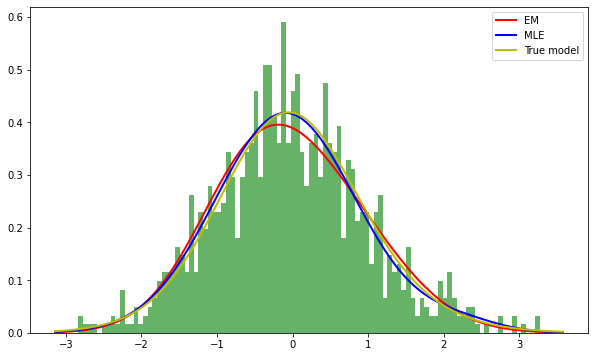

In [191]:
plt.figure(figsize=(10,6))
plt.hist(data, bins=100, density=True, alpha=0.6, color='g')

# EM
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = gmm.weights_[0] * norm.pdf(x, gmm.means_[0][0], np.sqrt(gmm.covariances_[0][0][0])) + \
    gmm.weights_[1] * norm.pdf(x, gmm.means_[1][0], np.sqrt(gmm.covariances_[1][0][0]))
plt.plot(x, p, 'k', linewidth=2,label = 'EM',color='r')

# MLE
p = res.x[4] * norm.pdf(x, res.x[0], res.x[2]) + \
    (1-res.x[4]) * norm.pdf(x, res.x[1], res.x[3])
plt.plot(x, p, 'k', linewidth=2,label = 'MLE',color='b')

#True Model
p = p1 * norm.pdf(x, u1, sigma_1_2**0.5) + \
    p2 * norm.pdf(x, u2, sigma_2_2**0.5)
plt.plot(x, p, 'k', linewidth=2,label = 'True model',color='y')
plt.legend ()
plt.show()

Calculate KL divergences between true model and EM/MLE model.

In [189]:
def kl_monte_carlo(params1, params2, num_samples=10**6):
    mu1_1, mu2_1, sigma1_1, sigma2_1, p1_1 = params1
    mu1_2, mu2_2, sigma1_2, sigma2_2, p1_2 = params2
    
    p2_1 = 1 - p1_1
    p2_2 = 1 - p1_2

    # Define the pdfs for each mixture of Gaussians
    def pdf_1(x):
        return p1_1 * norm.pdf(x, mu1_1, sigma1_1) + p2_1 * norm.pdf(x, mu2_1, sigma2_1)

    def pdf_2(x):
        return p1_2 * norm.pdf(x, mu1_2, sigma1_2) + p2_2 * norm.pdf(x, mu2_2, sigma2_2)
    
    # Sample from the first distribution
    Z = np.random.binomial(n=1, p=p1_1, size=num_samples)
    samples = Z * np.random.normal(mu1_1, sigma1_1, num_samples) + \
               (1-Z) * np.random.normal(mu2_1, sigma2_1, num_samples)
    
    # Calculate the Monte Carlo estimate of the KL divergence
    kl_divergence = np.mean(np.log(pdf_1(samples) / pdf_2(samples)))
    return kl_divergence

In [204]:
true_params = [u1, u2, sigma_1_2**0.5, sigma_2_2**0.5, p1]
EM_params =list(gmm.means_.ravel())+list(np.square(gmm.covariances_.ravel()))+ [gmm.weights_.ravel()[0]]
print('KL divergence between True model and EM : ',kl_monte_carlo(true_params, EM_params))
print('KL divergence between True model and MLE : ',kl_monte_carlo(true_params, res.x))

KL divergence between True model and EM :  0.3235318821838568
KL divergence between True model and MLE :  0.003148793295736422


Some findings:

MLE estimation is closer to true model than EM's. 

Although those distributions are similar, the value of distributional parameters are quit different. 

In [7]:
from __future__ import annotations
from arch.univariate.distribution import Distribution
from abc import ABCMeta, abstractmethod
from collections.abc import Sequence
from typing import Callable
import warnings

from numpy import (
    abs,    array,    asarray,    empty,    exp,    int64,    
    integer,    isscalar,    log,    nan,    ndarray, exp,
    ones_like,    pi,    sign,    sqrt,    sum, random)
from numpy.random import Generator, RandomState, default_rng
from scipy.special import comb, gamma, gammainc, gammaincc, gammaln
import scipy.stats as stats
from scipy.optimize import bisect

from arch.typing import ArrayLike, ArrayLike1D, Float64Array
from arch.utility.array import AbstractDocStringInheritor, ensure1d

class MixNormal(Distribution, metaclass=AbstractDocStringInheritor):
    """
    Mixture of two Normal distributions for use with SPARCH model

    Parameters
    ----------
    random_state : RandomState, optional
        .. deprecated:: 5.0

           random_state is deprecated. Use seed instead.

    seed : {int, Generator, RandomState}, optional
        Random number generator instance or int to use. Set to ensure
        reproducibility. If using an int, the argument is passed to
        ``np.random.default_rng``.  If not provided, ``default_rng``
        is used with system-provided entropy.
    """

    def __init__(
        self,
        random_state: RandomState | None = None,
        *,
        seed: None | int | RandomState | Generator = None,
    ) -> None:
        super().__init__(random_state=random_state, seed=seed)
        self._name = "Mixture of two Normal distributions"
        self.num_params: int = 3  

    def constraints(self) -> tuple[Float64Array, Float64Array]:
        return empty([0])

    def bounds(self, resids: Float64Array) -> list[tuple[float, float]]:
        """
        Bounds of parameters:
        p1: (0,1)
        u1: (-10,10)
        sigma_1:(0.001,10)
        """
        return [(0.05, 0.95),(-20,20),(0.2, 10)]

    def loglikelihood(
        self,
        parameters: Sequence[float] | ArrayLike1D,
        resids: ArrayLike,
        sigma2: ArrayLike,
        individual: bool = False,
    ) -> float | Float64Array:
        r"""Computes the log-likelihood of assuming residuals are mixture normally
        distributed, conditional on the variance

        Parameters
        ----------
        parameters : ndarray
            Parameters of the first normal distribution: p1,u1,sigma1. Second one can be calculated by restrictions.
        resids  : ndarray
            The residuals to use in the log-likelihood calculation
        sigma2 : ndarray
            Conditional variances of resids
        individual : bool, optional
            Flag indicating whether to return the vector of individual log
            likelihoods (True) or the sum (False)

        Returns
        -------
        ll : float
            The log-likelihood

        Notes
        -----
        The log-likelihood of a single data point x is

        .. math::

            \ln f\left(x\right)=
            \ln \frac{1}{\sqrt{h_t}} \left[
                 p_1  \frac{1}{\sqrt{ 2\pi\sigma_1^2} } exp\{ -\frac{(x-\mu_1)^2}{2\sigma_1^2} \}
                +(1-p_1)\frac{1}{\sqrt{ 2\pi\sigma_2^2} } exp\{ -\frac{(x-\mu_2)^2}{2\sigma_2^2} \} \right]

        """
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        z = resids/sqrt(sigma2)
        warnings.filterwarnings("ignore")
        lls =-1/2 *log(sigma2) +  log(   p1/(sqrt(2*pi*sigma_1_2)) *  exp(-( z-u1)**2/(2*sigma_1_2)) 
                                     +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
        warnings.filterwarnings("default")
          
        if individual:
            return lls
        else:
            return sum(lls)

    def starting_values(self, std_resid: Float64Array) -> Float64Array:
        """
        Starting values of parameters
        """
        #gmm = GaussianMixture(n_components=2).fit(std_resid.reshape(-1,1))
        #return array([gmm.weights_[0],gmm.means_ [0][0], gmm.covariances_[0][0][0] ])
        return array([0.5,-0.05,0.8])
    
    def _simulator(self, size: int | tuple[int, ...]) -> Float64Array:
        assert self._parameters is not None
        p1, u1, sigma_1_2 = self._parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        Z = np.random.binomial(n=1, p=p1, size=size)
        return sqrt(sigma_1_2)**Z*sqrt(sigma_2_2)**(1-Z)*self._generator.standard_normal(size) + u1*Z+ u2*(1-Z)

    def simulate(
        self, parameters: int | float | Sequence[float | int] | ArrayLike1D
    ) -> Callable[[int | tuple[int, ...]], Float64Array]:
        parameters = ensure1d(parameters, "parameters", False)
        self._parameters = asarray(parameters, dtype=float)
        return self._simulator

    def parameter_names(self) -> list[str]:
        return ['p_1','mu_1','sigma_1^2']

    def cdf(
        self,
        resids: Sequence[float] | ArrayLike1D,
        parameters: None | Sequence[float] | ArrayLike1D = None,
    ) -> Float64Array:
        self._check_constraints(parameters)
        
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        return p1*stats.norm.cdf(asarray((resids-u1)/sqrt(sigma_1_2))  ) + p2*stats.norm.cdf(asarray((resids-u2)/sqrt(sigma_2_2)))

    def ppf(
        self,
        pits: float | Sequence[float] | ArrayLike1D,
        parameters: None | Sequence[float] | ArrayLike1D = None,
    ) -> Float64Array:
        self._check_constraints(parameters)
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        scalar = isscalar(pits)
        if scalar:
            pits = array([pits])
        else:
            pits = asarray(pits)
            
        def inverse_cdf(cdf, target_p, lower_bound=-100, upper_bound=100):
            def root_func(x):
                return cdf(x,parameters) - target_p
            return bisect(root_func, lower_bound, upper_bound)     
        
        ppf = inverse_cdf(self.cdf, pits, lower_bound=-100, upper_bound=100)

        if scalar:
            return ppf[0]
        else:
            return ppf
        
   

    def moment(
        self, n: int, parameters: None | Sequence[float] | ArrayLike1D = None
    ) -> float:
        if n < 0:
            return nan
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        moment1 = stats.norm.moment(n,loc=u1,scale=sqrt(sigma_1_2))
        moment2 = stats.norm.moment(n,loc=u2,scale=sqrt(sigma_2_2))
        return p1 * moment1 + p2 * moment2

    def partial_moment(
        self,
        n: int,
        z: float = 0.0,
        parameters: None | Sequence[float] | ArrayLike1D = None,
        num_samples=100000,
    ) -> float:
        
        parameters = asarray(parameters, dtype=float)
        p1, u1, sigma_1_2 = parameters
        p2 = 1- p1
        u2 = p1/(p1-1) *u1
        sigma_2_2 = (1-p2*u2*u2-p1*(sigma_1_2+u2*u2))/(p2)
        
        if n < 0:
            return nan
        elif n == 0:
            return cdf(z,parameters)
        elif n==1:
            return -p1*stats.norm.pdf(z,loc=u1,scale=sqrt(sigma_1_2))  -p2*stats.norm.pdf(z,loc=u2,scale=sqrt(sigma_2_2))
        else:
            -(z ** (n - 1)) * (p1*stats.norm.pdf(z,loc=u1,scale=sqrt(sigma_1_2))+p2*stats.norm.pdf(z,loc=u2,scale=sqrt(sigma_2_2))) 
            + (n - 1) * self.partial_moment(  n - 2, z, parameters  )

In [47]:
best_aic = 400
best_summary = None
for i in range(500):
    starting_values = np.concatenate( (np.array(gjr_normal.params),dparams )   )
    sparch21 = arch_model(y=Y,x=X, mean=mean, vol='GARCH',p=2, o=2, q=1,lags=lags)
    sparch21.distribution = MixNormal()
    '''    try:
        gjr_MixNormal=sparch21.fit(disp='off',cov_type=cov,options=options,starting_values=starting_values )
          # If the fitting is successful, break the loop
    except:'''
    gjr_MixNormal=sparch21.fit(disp='off',cov_type=cov,options=options,starting_values=starting_values )
    if best_aic > gjr_MixNormal.aic:
        best_params = np.array(gjr_MixNormal.params)
        best_aic = gjr_MixNormal.aic
        best_summary = gjr_MixNormal.summary()
        print(best_summary)
    dparams =  np.array(  [ np.random.uniform(),np.random.uniform()*10-5, np.random.uniform()] )
                       
        
best_summary

D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: invalid value encountered in sqrt
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: overflow encountered in exp
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:106: RuntimeWarning: divide by zero encountered in log
  lls =-1/2 *log(sigma2) +  log(   p1/(sqrt(2*pi*sigma_1_2)) *  exp(-( z-u1)**2/(2*sigma_1_2))
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional

                              Zero Mean - GJR-GARCH Model Results                              
Dep. Variable:                         Inflation shock   R-squared:                       0.000
Mean Model:                                  Zero Mean   Adj. R-squared:                  0.005
Vol Model:                                   GJR-GARCH   Log-Likelihood:               -171.860
Distribution:      Mixture of two Normal distributions   AIC:                           361.719
Method:                             Maximum Likelihood   BIC:                           391.757
                                                         No. Observations:                  208
Date:                                 Wed, Jul 12 2023   Df Residuals:                      208
Time:                                         22:23:57   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     9

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: invalid value encountered in sqrt
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: overflow encountered in exp
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:106: RuntimeWarning: divide by zero encountered in log
  

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: invalid value encountered in sqrt
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: overflow encountered in exp
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:106: RuntimeWarning: divide by zero encountered in log
  

D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: invalid value encountered in sqrt
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: overflow encountered in exp
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:106: RuntimeWarning: divide by zero encountered in log
  lls =-1/2 *log(sigma2) +  log(   p1/(sqrt(2*pi*sigma_1_2)) *  exp(-( z-u1)**2/(2*sigma_1_2))
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional

...

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: invalid value encountered in sqrt
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: overflow encountered in exp
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:106: RuntimeWarning: divide by zero encountered in log
  

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: invalid value encountered in sqrt
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: overflow encountered in exp
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:106: RuntimeWarning: divide by zero encountered in log
  

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: invalid value encountered in sqrt
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: overflow encountered in exp
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:106: RuntimeWarning: divide by zero encountered in log
  

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:704: StartingValueWarning: Starting values do not satisfy the parameter constraints in the model.  The
provided starting values will be ignored.

  warnings.warn(starting_value_warning, StartingValueWarning)
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: invalid value encountered in sqrt
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:107: RuntimeWarning: overflow encountered in exp
  +   p2/(sqrt(2*pi*sigma_2_2)) *  exp(-( z-u2)**2/(2*sigma_2_2))   )
C:\Users\ADMINI~1\AppData\Local\Temp/ipykernel_15172/314617582.py:106: RuntimeWarning: divide by zero encountered in log
  

<class 'statsmodels.iolib.summary.Summary'>
"""
                              Zero Mean - GJR-GARCH Model Results                              
===============================================================================================
Dep. Variable:                         Inflation shock   R-squared:                       0.000
Mean Model:                                  Zero Mean   Adj. R-squared:                  0.005
Vol Model:                                   GJR-GARCH   Log-Likelihood:               -171.860
Distribution:      Mixture of two Normal distributions   AIC:                           361.719
Method:                             Maximum Likelihood   BIC:                           391.757
                                                         No. Observations:                  208
Date:                                 Wed, Jul 12 2023   Df Residuals:                      208
Time:                                         22:23:57   Df Model:                            0
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1271  4.431e-02      2.868  4.133e-03  [4.023e-02,  0.214]
alpha[1]       0.2339      0.154      1.523      0.128 [-6.702e-02,  0.535]
alpha[2]       0.7756      0.345      2.251  2.438e-02    [  0.100,  1.451]
gamma[1]      -0.0973      0.166     -0.587      0.557    [ -0.422,  0.228]
gamma[2]      -0.7756      0.338     -2.297  2.165e-02    [ -1.438, -0.114]
beta[1]        0.1036      0.125      0.831      0.406    [ -0.141,  0.348]
                                 Distribution                                
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
p_1        1.0073e-03  6.244e-04      1.613      0.107 [-2.165e-04,2.231e-03]
mu_1        -100.0000     69.601     -1.437      0.151   [-2.364e+02, 36.415]
sigma_1^2  1.0000e-03    129.407  7.728e-06      1.000 [-2.536e+02,2.536e+02]
=============================================================================

Covariance estimator: robust
WARNING: The optimizer did not indicate successful convergence. The message was Positive directional derivative for linesearch.
See convergence_flag.

"""

In [47]:
Y = sample_data['Inflation shock']
mean='Zero'
best_aic = 400
best_init_val = []
best_summary = 0
for p1 in np.linspace(0.5, 1, 10):
    for mu1 in np.linspace(-2, 2, 10):
        for sigma in np.linspace(0.001, 1.2, 10):
            warnings.filterwarnings("ignore")
            model = SPARCH(Y,[p1,mu1,sigma],X,mean='Zero', vol='GARCH',p=1,q=1,lags=None,cov = 'robust')
            warnings.filterwarnings("default")
            if model.aic < best_aic:
                best_aic = model.aic
                best_init_val = [p1,mu1,sigma]
                best_summary = model.summary()
                
best_summary

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariat

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariat

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariat

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariat

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariat

...

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariat

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariat

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariat

D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariate\base.py:759: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
D:\anaconda\lib\site-packages\arch\univariat

<class 'statsmodels.iolib.summary.Summary'>
"""
                                Zero Mean - GARCH Model Results                                
===============================================================================================
Dep. Variable:                         Inflation shock   R-squared:                       0.000
Mean Model:                                  Zero Mean   Adj. R-squared:                  0.005
Vol Model:                                       GARCH   Log-Likelihood:               -190.580
Distribution:      Mixture of two Normal distributions   AIC:                           393.161
Method:                             Maximum Likelihood   BIC:                           413.186
                                                         No. Observations:                  208
Date:                                 Thu, Jul 13 2023   Df Residuals:                      208
Time:                                         14:24:29   Df Model:                            0
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0769  2.365e-02      3.252  1.144e-03 [3.056e-02,  0.123]
alpha[1]       0.3625  6.049e-02      5.994  2.051e-09   [  0.244,  0.481]
beta[1]        0.4809      0.131      3.660  2.520e-04   [  0.223,  0.738]
                                 Distribution                                
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
p_1            0.0102  1.199e-02      0.850      0.395 [-1.331e-02,3.369e-02]
mu_1          -1.5326      0.127    -12.043  2.117e-33      [ -1.782, -1.283]
sigma_1^2  1.0000e-03  1.014e-03      0.987      0.324 [-9.865e-04,2.987e-03]
=============================================================================

Covariance estimator: robust
WARNING: The optimizer did not indicate successful convergence. The message was Positive directional derivative for linesearch.
See convergence_flag.

"""